In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

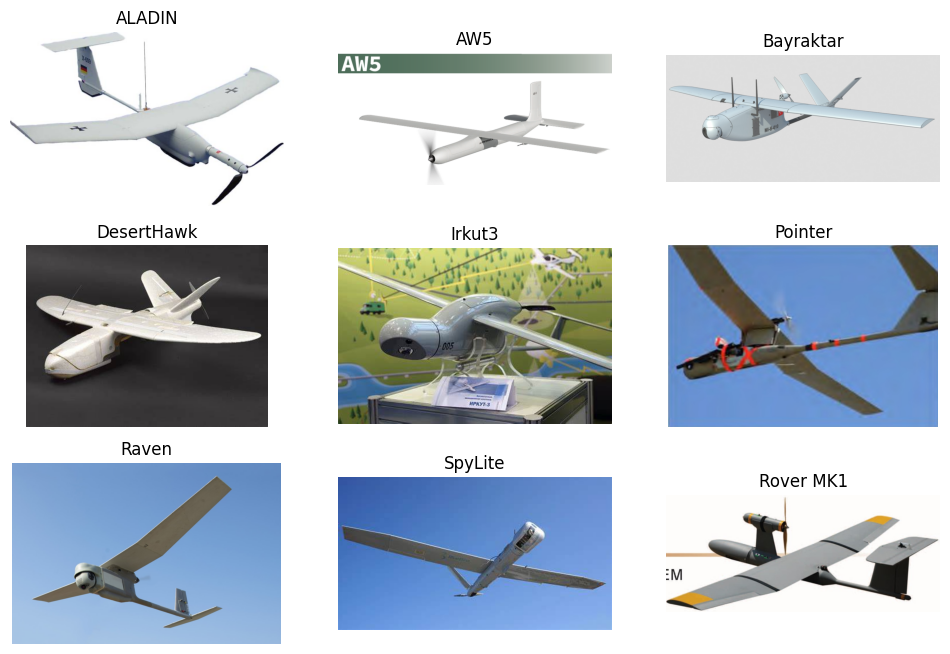

In [50]:
UAV = ['ALADIN', 'AW5', 'Bayraktar', 'DesertHawk', 'Irkut3', 'Pointer', 'Raven', 'SpyLite', 'Rover MK1']
im = []
for el in UAV:
    im.append(Image.open(f'{el}.jpg'))
fig, ax = plt.subplots(3,3, figsize=(12,8))
ax = ax.ravel()
i=0
for el in im:
    ax[i].imshow(el)
    ax[i].axis('off')
    ax[i].set_title(f'{UAV[i]}')
    i+=1
# plt.savefig('UAVs.png')

In [51]:
data = pd.read_csv("WeightData.csv")
Ratio = data.iloc[[1,2,3,6,7,9,11,17,18,22],-1].to_numpy()
Weight = data.iloc[[1,2,3,6,7,9,11,17,18,22],1].to_numpy()


BatWeight = data.iloc[[1,3,6,7,9,11,17,18,22], 3].to_numpy()
BatRatio = BatWeight / np.concatenate((Weight[0:1], Weight[2:]), axis=0)

WingSpan = data.iloc[:, 5].to_numpy()
TotWeight = data.iloc[:, 1].to_numpy()
Name = data.iloc[:, 0].to_list()
Name

['Raven',
 'Pointer',
 'BayraktarB',
 'Guardian',
 'CYGNUS',
 'CSV 15',
 'ALADIN',
 'DesertHawk',
 'DragonEye',
 'Irkut3',
 'SpyLite',
 'EOSMini',
 'AW5',
 'AW6',
 'AW15',
 'Altius-600',
 'RAM2',
 'Rover MK1',
 'Rover XS',
 'jm-1',
 'Warmate',
 'StreamC',
 'Albatross',
 'Black knight',
 'WARble',
 'Fire Cardinal',
 'Fedai 101']

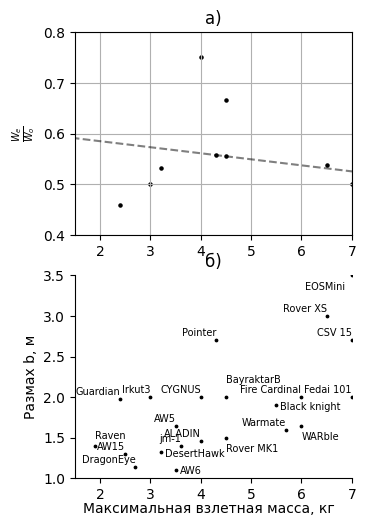

In [109]:
fig, ax = plt.subplots(2,1, figsize=((90/25.2),(146/25.2)))
ax.ravel()
ax[0].scatter((Weight), Ratio, c='black', s = 5)
p = np.polyfit((Weight), Ratio, 1)
p1 = np.polyfit(BatWeight, BatRatio, 1)
ax[0].plot(np.linspace(1, 11), np.polyval(p, np.linspace(1, 11)), color='black', linestyle="--", alpha = 0.5) # label='Best fit' + '\n' + f'k = {round(p[0], 2)}' + '\n' + f'b = {round(p[1], 2)}'
# ax[0].set_xlabel(r"Пустой вес $W_0$, kg")
ax[0].set_ylabel(r"$\frac{W_e}{W_o}$")
ax[0].grid('Major')
ax[0].set_xlim(1.5, 7)
ax[0].set_ylim(0.4, 0.8)
ax[0].set_title("a)")
# ax[0].legend(fontsize = 11)
# ax[1].scatter(BatWeight, BatRatio, c='black')
# ax[1].plot(np.linspace(0, 2), np.polyval(p1, np.linspace(0, 2)), color='black')
# ax[1].grid('Major')
# # ax[1].set_xlim(2, 11)
# # ax[1].set_ylim(0.1, 0.5)
# ax[1].plot(np.linspace(0, 2), np.polyval(p1, np.linspace(0, 2)))
# ax[1].legend(fontsize=11)


ax[1].scatter(TotWeight, WingSpan, c="black", s = 3)

for i, txt in enumerate(Name):
    if i!=0 and i != 11 and i != 2 and i != 17 and i!=24 and i!=23 and i!=13 and i!=7:
        ax[1].annotate(txt, (TotWeight[i], WingSpan[i]), textcoords="offset points", xytext=(0,3), ha='right', size=7)

ax[1].annotate(Name[0], (TotWeight[0], WingSpan[0]), textcoords="offset points", xytext=(0,5), ha='left', size=7)

ax[1].annotate(Name[11], (TotWeight[11], WingSpan[11]), textcoords="offset points", xytext=(-5,-10), ha='right', size=7)
ax[1].annotate(Name[2], (TotWeight[2], WingSpan[2]), textcoords="offset points", xytext=(0,10), ha='left', size=7)
ax[1].annotate(Name[17], (TotWeight[17], WingSpan[17]), textcoords="offset points", xytext=(0,-10), ha='left', size=7)
ax[1].annotate(Name[24], (TotWeight[24], WingSpan[24]), textcoords="offset points", xytext=(0,-10), ha='left', size=7)
ax[1].annotate(Name[23], (TotWeight[23], WingSpan[23]), textcoords="offset points", xytext=(3,-3), ha='left', size=7)
ax[1].annotate(Name[13], (TotWeight[13], WingSpan[13]), textcoords="offset points", xytext=(3,-3), ha='left', size=7)
ax[1].annotate(Name[7], (TotWeight[7], WingSpan[7]), textcoords="offset points", xytext=(3,-3), ha='left', size=7)
ax[1].set_title("б)")

ax[1].set_xlim(1.5, 7)
ax[1].set_ylim(1, 3.5)
# ax[1].set_xlabel(r"Максимальная взлетная масса, кг")
ax[1].set_ylabel(r"Размах b, м")
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
fig.text(0.5, 0.05, 'Максимальная взлетная масса, кг', ha='center')
# print(p, p1)
# print(np.mean(Ratio), np.std(Ratio))
# print(np.mean(BatRatio), np.std(BatRatio))
plt.savefig("Statistics_Vert.png", dpi=300, bbox_inches = "tight", pad_inches = 0)